In [1]:
import threading

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyBigWig as pbw
import seaborn as sns
import torch
from torch import nn
from torch.nn.parallel import DataParallel
from torch.utils.data import DataLoader, Dataset, Sampler
from torch.utils.tensorboard import SummaryWriter

In [2]:
from diffusers import UNet1DModel

In [3]:
LOGDIR = "../data/logdir/tensorboards/"
writer = SummaryWriter(LOGDIR)

In [4]:
EXO_PATH = "../data/reads/S_cerevisiae/SRR1802184/SRR1802184.bw"
exo_bw = pbw.open(EXO_PATH)

In [5]:
MNASE_PATH = "../data/reads/S_cerevisiae_mnase_only/SRR1802180/SRR1802180.bw"
mnase_bw = pbw.open(MNASE_PATH)

In [6]:
exo_bw.chroms()

{'NC_001133.9': 230218,
 'NC_001134.8': 813184,
 'NC_001135.5': 316620,
 'NC_001136.10': 1531933,
 'NC_001137.3': 576874,
 'NC_001138.5': 270161,
 'NC_001139.9': 1090940,
 'NC_001140.6': 562643,
 'NC_001141.2': 439888,
 'NC_001142.9': 745751,
 'NC_001143.9': 666816,
 'NC_001144.5': 1078177,
 'NC_001145.3': 924431,
 'NC_001146.8': 784333,
 'NC_001147.6': 1091291,
 'NC_001148.4': 948066,
 'NC_001224.1': 85779}

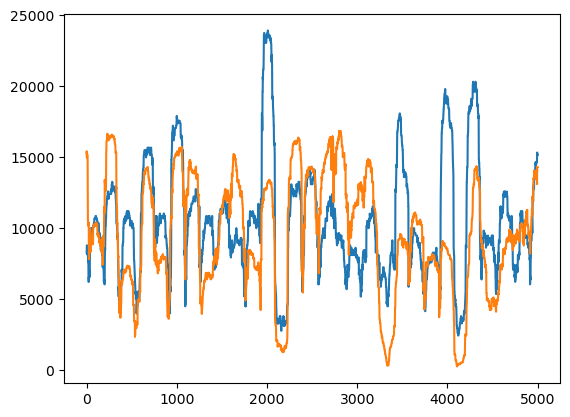

In [7]:
v1 = np.array(exo_bw.values("NC_001136.10", 30000, 35000))
v2 = np.array(mnase_bw.values("NC_001136.10", 30000, 35000))


plt.plot(v1)
plt.plot(v2)

In [9]:
class BigWigPairedDataset(Dataset):
    def __init__(self, path1, path2, chromosomes, window_size, npoints):
        self.path1 = path1  # Store paths instead of file objects
        self.path2 = path2
        self.chromosomes = chromosomes
        self.window_size = window_size
        self.npoints = npoints

        # Pre-compute valid intervals
        self.data = self.__compute_data()

        # Thread-local storage for file handles
        self._local = threading.local()

    def _get_file(self, path):
        """Get file handle for current thread"""
        if not hasattr(self._local, "file_handles"):
            self._local.file_handles = {}

        if path not in self._local.file_handles:
            self._local.file_handles[path] = pbw.open(path)

        return self._local.file_handles[path]

    def __compute_data(self):
        """Pre-compute valid intervals with bounds checking"""
        # Open temporary files to check chromosome sizes
        with pbw.open(self.path1) as file1, pbw.open(self.path2) as file2:
            data = []
            attempts = 0
            max_attempts = self.npoints * 10  # Prevent infinite loops

            while len(data) < self.npoints and attempts < max_attempts:
                cur_chromo = np.random.choice(self.chromosomes)

                # Get chromosome size from both files
                if cur_chromo not in file1.chroms() or cur_chromo not in file2.chroms():
                    attempts += 1
                    continue

                max_chromo_len1 = file1.chroms()[cur_chromo]
                max_chromo_len2 = file2.chroms()[cur_chromo]

                # Use the smaller chromosome size to be safe
                max_chromo_len = min(max_chromo_len1, max_chromo_len2)

                if max_chromo_len <= self.window_size:
                    attempts += 1
                    continue

                cur_start = np.random.randint(0, max_chromo_len - self.window_size)
                cur_stop = cur_start + self.window_size

                data.append((cur_chromo, cur_start, cur_stop))
                attempts += 1

            if len(data) < self.npoints:
                print(
                    f"Warning: Only generated {len(data)} valid intervals out of {self.npoints}"
                )

            return data

    def __get_signal(self, item, file_path):
        """Safely get signal with error handling"""
        cur_chromo, cur_start, cur_stop = self.data[item]

        try:
            file = self._get_file(file_path)
            values = file.values(cur_chromo, cur_start, cur_stop)

            if values is None:
                # Return zeros if the query failed
                return torch.zeros(self.window_size).float()

            # Replace None values with 0 and handle any issues
            cleaned_values = []
            for v in values:
                if v is None or np.isnan(v):
                    cleaned_values.append(0.0)
                else:
                    cleaned_values.append(float(v))

            return torch.tensor(cleaned_values).float()

        except Exception as e:
            print(
                f"Error reading {file_path} at {cur_chromo}:{cur_start}-{cur_stop}: {e}"
            )
            return torch.zeros(self.window_size).float()

    def __getitem__(self, item):
        res = {
            "file1": self.__get_signal(item, self.path1),
            "file2": self.__get_signal(item, self.path2),
        }
        return res

    def __len__(self):
        return len(self.data)

    def __del__(self):
        """Clean up file handles"""
        if hasattr(self, "_local") and hasattr(self._local, "file_handles"):
            for file in self._local.file_handles.values():
                try:
                    file.close()
                except:
                    pass

In [10]:
chromosomes = list(exo_bw.chroms().keys())
chromosomes.remove("NC_001144.5")
win_size = 1024 * 2

exo_dataset = BigWigPairedDataset(MNASE_PATH, EXO_PATH, chromosomes, win_size, 100000)
train_dataset, test_dataset = torch.utils.data.random_split(exo_dataset, [0.7, 0.3])
val_dataset, test_dataset = torch.utils.data.random_split(test_dataset, [0.5, 0.5])

In [25]:
batch_size = 100

train_loader = DataLoader(exo_dataset, batch_size, True, num_workers=16)
val_loader = DataLoader(val_dataset, batch_size, True, num_workers=16)
test_loader = DataLoader(test_dataset, batch_size, True, num_workers=16)

In [26]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from torch.utils.data import DataLoader
from tqdm import tqdm


def train_epoch(model, dataloader, criterion, optimizer, device):
    """Одна эпоха тренировки"""
    model = model.to(device)
    running_loss = 0.0
    all_predictions = []
    all_targets = []

    for idx, batch in enumerate(tqdm(dataloader, desc="Training")):
        # Перемещаем данные на устройство
        data, targets = batch["file1"].float().to(device), batch["file2"].float().to(
            device
        )
        data = torch.unsqueeze(data, 1)
        targets = torch.unsqueeze(targets, 1)

        # Обнуляем градиенты
        optimizer.zero_grad()

        # Прямой проход
        timesteps = torch.ones(data.shape[0]).to(device)
        outputs = model(data, timesteps).sample
        print(outputs)
        loss = criterion(outputs, targets)

        # Обратный проход
        loss.backward()
        optimizer.step()

        # Собираем статистику
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

    # Вычисляем метрики
    epoch_loss = running_loss / len(dataloader)
    return epoch_loss


def validate_epoch(model, dataloader, criterion, device):
    """Валидация модели"""
    model.eval()
    model = model.to(device)
    running_loss = 0.0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for idx, batch in tqdm(enumerate(dataloader), desc="Validation"):
            data, targets = batch["file1"].float().to(device), batch[
                "file2"
            ].float().to(device)
            data = torch.unsqueeze(data, 1)
            targets = torch.unsqueeze(targets, 1)
            timesteps = torch.ones(data.shape[0]).to(device)

            outputs = model(data, timesteps).sample
            loss = criterion(outputs, targets)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    epoch_loss = running_loss / idx
    return epoch_loss


def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs,
    writer=None,
    early_stopping_patience=5,
):
    """Полный цикл тренировки модели"""

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    best_val_loss = float("inf")
    patience_counter = 0
    best_model_weights = None

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 50)

        # Тренировка
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        train_losses.append(train_loss)

        # Валидация
        val_loss = validate_epoch(model, val_loader, criterion, device)
        val_losses.append(val_loss)

        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Loss: {val_loss:.4f}")

        if writer:
            writer.add_scalar("Loss/train", train_loss, epoch)
            writer.add_scalar("Loss/val", val_loss, epoch)

    #         # Early Stopping
    #         if val_loss < best_val_loss:
    #             best_val_loss = val_loss
    #             best_model_weights = model.state_dict().copy()
    #             patience_counter = 0
    #             print(f'New best model saved! Val Loss: {val_loss:.4f}')
    #         else:
    #             patience_counter += train_model
    #             print(f'Early stopping counter: {patience_counter}/{early_stopping_patience}')

    #             if patience_counter >= early_stopping_patience:
    #                 print("Early stopping triggered!")
    #                 break

    # Загружаем веса лучшей модели
    if best_model_weights:
        model.load_state_dict(best_model_weights)

    return {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
    }

In [27]:
def train_epoch_dataparallel(model, dataloader, criterion, optimizer, device, logdir):
    """Одна эпоха тренировки с DataParallel"""
    model.train()
    running_loss = 0.0
    all_predictions = []
    all_targets = []

    for idx, batch in enumerate(tqdm(dataloader, desc="Training", leave=False)):
        # Перемещаем данные на устройство
        data, targets = batch["file1"].float().to(device), batch["file2"].float().to(
            device
        )
        data = torch.unsqueeze(data, 1)
        targets = torch.unsqueeze(targets, 1)

        # Обнуляем градиенты
        optimizer.zero_grad()

        # Прямой проход с DataParallel
        timesteps = torch.ones(data.shape[0]).to(device)

        # DataParallel автоматически распределит данные по GPU
        if isinstance(model, DataParallel):
            outputs = model.module(data, timesteps).sample
        else:
            outputs = model(data, timesteps).sample

        loss = criterion(outputs, targets)

        # Обратный проход
        loss.backward()
        optimizer.step()

        # Собираем статистику
        running_loss += loss.item() / len(data)
        _, predicted = torch.max(outputs.data, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

    # Вычисляем метрики
    epoch_loss = running_loss / len(dataloader)
    return epoch_loss


def validate_epoch_dataparallel(model, dataloader, criterion, device):
    """Валидация модели с DataParallel"""
    model.eval()
    running_loss = 0.0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for idx, batch in tqdm(enumerate(dataloader), desc="Validation", leave=False):
            data, targets = batch["file1"].float().to(device), batch[
                "file2"
            ].float().to(device)
            data = torch.unsqueeze(data, 1)
            targets = torch.unsqueeze(targets, 1)
            timesteps = torch.ones(data.shape[0]).to(device)

            # DataParallel для валидации
            if isinstance(model, DataParallel):
                outputs = model.module(data, timesteps).sample
            else:
                outputs = model(data, timesteps).sample

            loss = criterion(outputs, targets)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    epoch_loss = (
        running_loss / len(data) / len(dataloader)
    )  # Исправлено: +1 чтобы избежать деления на 0
    return epoch_loss


def train_model_dataparallel(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs,
    logdir,
    device_ids=None,
    writer=None,
    early_stopping_patience=5,
):
    """Полный цикл тренировки модели с DataParallel"""

    model = model.to(device)

    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    patience_counter = 0
    best_model_weights = None

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 50)

        # Тренировка
        train_loss = train_epoch_dataparallel(
            model, train_loader, criterion, optimizer, device, logdir
        )
        train_losses.append(train_loss)

        # Валидация
        val_loss = validate_epoch_dataparallel(model, val_loader, criterion, device)
        val_losses.append(val_loss)

        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Loss: {val_loss:.4f}")

        if writer:
            writer.add_scalar("Loss/train", train_loss, epoch)
            writer.add_scalar("Loss/val", val_loss, epoch)

        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            # Сохраняем веса оригинальной модели (без DataParallel wrapper)
            if isinstance(model, DataParallel):
                best_model_weights = model.module.state_dict().copy()
                torch.save(model, logdir)
            else:
                best_model_weights = model.state_dict().copy()
            patience_counter = 0
            print(f"New best model saved! Val Loss: {val_loss:.4f}")
        else:
            patience_counter += 1
            print(
                f"Early stopping counter: {patience_counter}/{early_stopping_patience}"
            )

            if patience_counter >= early_stopping_patience:
                print("Early stopping triggered!")
                break

    # Загружаем веса лучшей модели
    if best_model_weights:
        if isinstance(model, DataParallel):
            model.module.load_state_dict(best_model_weights)
        else:
            model.load_state_dict(best_model_weights)

    # Возвращаем оригинальную модель (без DataParallel wrapper)
    final_model = model.module if isinstance(model, DataParallel) else model

    return {
        "model": final_model,
        "train_losses": train_losses,
        "val_losses": val_losses,
    }

In [28]:
unet_model = UNet1DModel(
    sample_size=win_size,  # Length of the 1D signal
    in_channels=1,  # Input channels (e.g., mono audio)
    out_channels=1,  # Output channels
    layers_per_block=3,
    block_out_channels=(128, 128, 128, 256, 256, 256, 512, 512),
    down_block_types=(
        "DownBlock1D",  # Standard downsampling
        "DownBlock1D",
        "DownBlock1D",  # Standard downsampling
        "DownBlock1D",
        "DownBlock1D",  # Standard downsampling
        "AttnDownBlock1D",  # Downsampling with attention
        "AttnDownBlock1D",
        "AttnDownBlock1D",  # Downsampling with attention
    ),
    up_block_types=(
        "AttnUpBlock1D",  # Upsampling with attention
        "AttnUpBlock1D",
        "AttnUpBlock1D",  # Upsampling with attention
        "UpBlock1D",  # Standard upsampling
        "UpBlock1D",
        "UpBlock1D",
        "UpBlock1D",
        "UpBlock1D",
    ),
)

In [29]:
import torch.distributed as dist

model = DataParallel(unet_model, [0, 1], dim=1)

In [30]:
mse_loss = torch.nn.L1Loss()
adam = torch.optim.AdamW(model.parameters())

In [31]:
val_res = train_model_dataparallel(
    model,
    train_loader,
    val_loader,
    mse_loss,
    adam,
    "cuda",
    200,
    "../data/logdir/models/best_model_4att_4000ws.torch",
    [0, 1],
    writer,
    100,
)

Epoch 1/200
--------------------------------------------------


Train Loss: 41.8974
Val Loss: 27.4307
New best model saved! Val Loss: 27.4307
Epoch 2/200
--------------------------------------------------


Train Loss: 26.5242
Val Loss: 25.4946
New best model saved! Val Loss: 25.4946
Epoch 3/200
--------------------------------------------------


Train Loss: 25.0217
Val Loss: 24.8692
New best model saved! Val Loss: 24.8692
Epoch 4/200
--------------------------------------------------


Train Loss: 25.7084
Val Loss: 25.5923
Early stopping counter: 1/100
Epoch 5/200
--------------------------------------------------


...

Train Loss: 25.6980
Val Loss: 25.2155
Early stopping counter: 4/100
Epoch 16/200
--------------------------------------------------


Train Loss: 25.7283
Val Loss: 25.9683
Early stopping counter: 5/100
Epoch 17/200
--------------------------------------------------


Train Loss: 25.5919
Val Loss: 25.4888
Early stopping counter: 6/100
Epoch 18/200
--------------------------------------------------


Train Loss: 2335.6064
Val Loss: 26.9683
Early stopping counter: 7/100
Epoch 19/200
--------------------------------------------------


                                                            
KeyboardInterrupt



In [50]:
model = torch.load("../data/logdir/models/best_model_4att_.torch", weights_only=False)

In [62]:
def test_epoch_dataparallel(model, dataloader, criterion, device):
    """Валидация модели с DataParallel"""
    model.eval()
    running_loss = 0.0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for idx, batch in tqdm(enumerate(dataloader), desc="Validation", leave=False):
            data, targets = batch["file1"].float().to(device), batch[
                "file2"
            ].float().to(device)
            data = torch.unsqueeze(data, 1)
            targets = torch.unsqueeze(targets, 1)
            timesteps = torch.ones(data.shape[0]).to(device)

            # DataParallel для валидации
            if isinstance(model, DataParallel):
                outputs = model.module(data, timesteps).sample
            else:
                outputs = model(data, timesteps).sample

            loss = criterion(outputs, targets)

            running_loss += loss.item()
            all_predictions.extend(outputs.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    loss_by_nuc = running_loss / (idx + 1) / len(data)
    return loss_by_nuc, all_predictions, all_targets

In [63]:
test_loss, test_pred, test_targsts = test_epoch_dataparallel(
    model, test_loader, mse_loss, "cuda"
)

In [64]:
print(test_loss)

24.433272737630208


In [54]:
test_pred = np.squeeze(test_pred, 1)
test_targsts = np.squeeze(test_targsts, 1)

In [55]:
import numpy as np

# Calculate correlation between corresponding rows
correlations = []
for i in range(min(test_pred.shape[0], test_targsts.shape[0])):
    corr = np.corrcoef(test_pred[i], test_targsts[i])[0, 1]
    correlations.append(corr)

correlations = np.array(correlations)

/home/d_ryabov/.conda/envs/newNucDPosIT/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/d_ryabov/.conda/envs/newNucDPosIT/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


<Axes: ylabel='Count'>

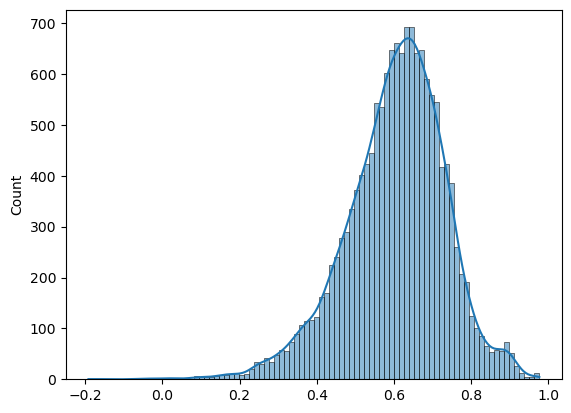

In [56]:
sns.histplot(correlations, kde=True)

In [57]:
df = pd.DataFrame(test_targsts - test_pred)

<Axes: >

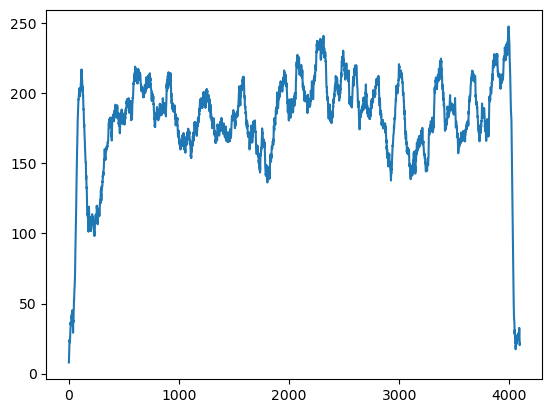

In [58]:
df.mean(0).plot()

<Axes: >

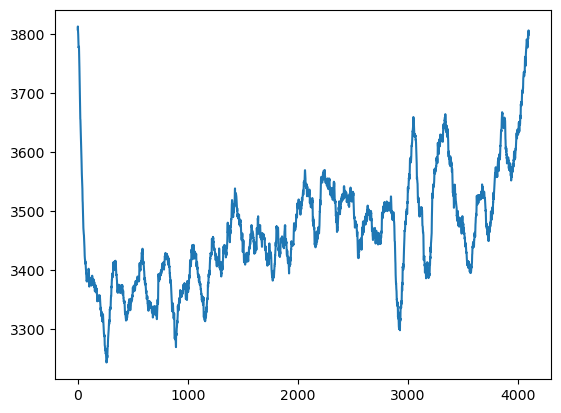

In [59]:
df.std(0).plot()

In [60]:
test_pred

array([[12284.838 , 12284.839 , 12159.41  , ..., 11305.792 , 11336.166 ,
        11336.166 ],
       [ 2415.9373,  2415.9375,  2411.5437, ...,  7915.877 ,  7916.671 ,
         7916.671 ],
       [ 2980.964 ,  2980.9644,  2977.759 , ...,  5079.297 ,  5087.9077,
         5087.907 ],
       ...,
       [26123.885 , 26123.887 , 26074.297 , ..., 11109.554 , 11183.604 ,
        11183.604 ],
       [ 8841.335 ,  8841.334 ,  8883.235 , ...,  3999.8096,  4034.343 ,
         4034.3425],
       [ 9936.384 ,  9936.384 ,  9943.1455, ..., 10503.666 , 10512.925 ,
        10512.925 ]], shape=(15000, 4096), dtype=float32)

In [ ]:
sns.scatterplot(x=test_pred.flatten(), y=test_targsts.flatten())

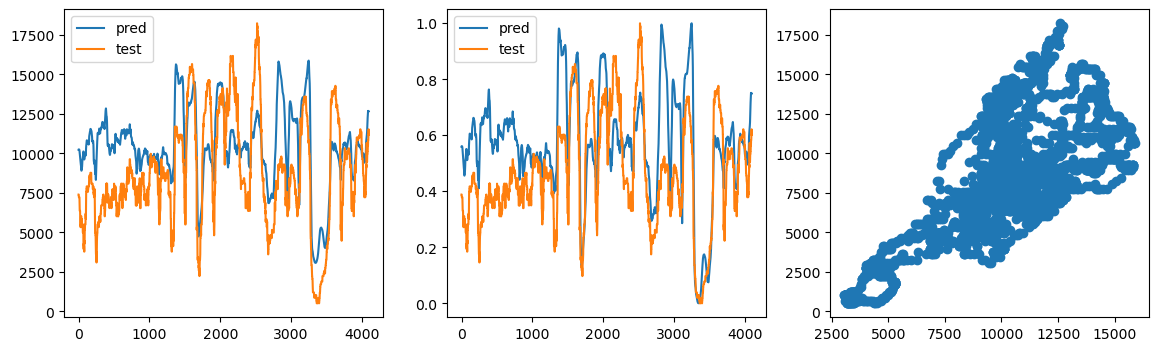

In [48]:
idx = 180


target = test_targsts[idx].flatten()
target_normed = (target - target.min()) / (target.max() - target.min())


out = test_pred[idx].flatten()
out_normed = (out - out.min()) / (out.max() - out.min())


fig, axs = plt.subplots(1, 3, figsize=(14, 4))
axs[0].plot(out, label="pred")
axs[0].plot(target, label="test")
axs[0].legend()

axs[1].plot(out_normed, label="pred")
axs[1].plot(target_normed, label="test")
axs[1].legend()

axs[2].scatter(out, target)